In [ ]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape
import sklearn

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)

def sigmoid(x):
    return 1/(1+np.exp(-x))

# Make cyclone maps

In [2]:
cluster = LocalCluster(n_workers=8, memory_limit='12GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 64,Total memory: 96.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45741,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43917,Total threads: 8
Dashboard: http://127.0.0.1:41345/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:46707,


In [3]:
ds_features = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr").load()

In [41]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
# run_id = '75kakckt'

# run_id = 'wisxbydg'
# run_id = 'g4xjud02'
# run_id = 'bd4apy6o'
run_id ='ima3ba04'

# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()

ds_predictions = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_model_skill.nc')
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc').transpose('y','x',...)
ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
ds_attrs['moran_I'] = ds_moran.Moran_I

lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed

# ig_normed = ds_attrs.attributions_ig 
# ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# # cycs = cycs.query("msl<100000")
gdf_cyclones = gpd.read_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data.geojson')
gdf_cyclones['blob_pixel_count'] = (gdf_cyclones.blob_area/1.384083e+04).round(1)
gdf_cyclones = gdf_cyclones.set_crs(proj, allow_override=True)
all_cyclones = gpd.read_file('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson')
all_cyclones = all_cyclones.set_crs(proj, allow_override=True)


In [74]:
ds_predictions
ds_rain = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')
# ds_rain.tp.isel(time=range(10)).plot()
rain = xr.concat([ds_rain.tp.shift(time=-k).assign_coords(timestep=k) for k in range(7)], dim='timestep')
ds_predictions['rain'] = rain
# .isel(time=range(10)).plot()

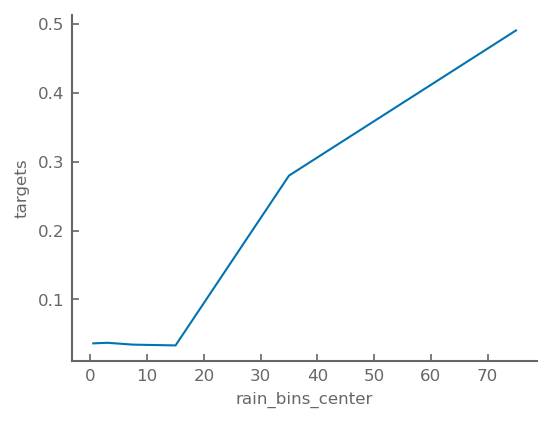

In [81]:
ds_predictions.mean('dataset').groupby_bins('rain', bins=[0,1,5,10,20,50,100]).mean().targets.plot()

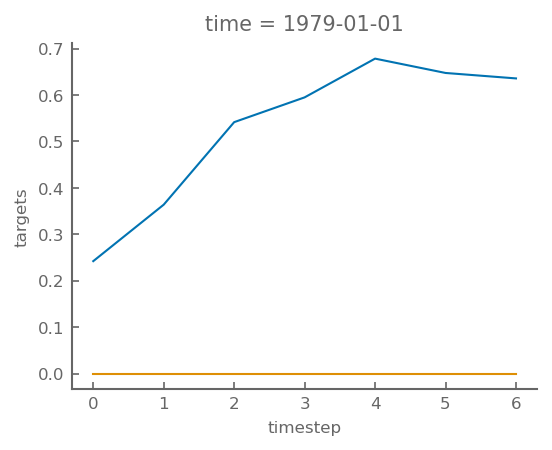

In [55]:
ds_predictions.predictions.isel(time=0).mean('dataset').plot()
ds_predictions.targets.isel(time=0).mean('dataset').plot()

<Axes: xlabel='timestep_past'>

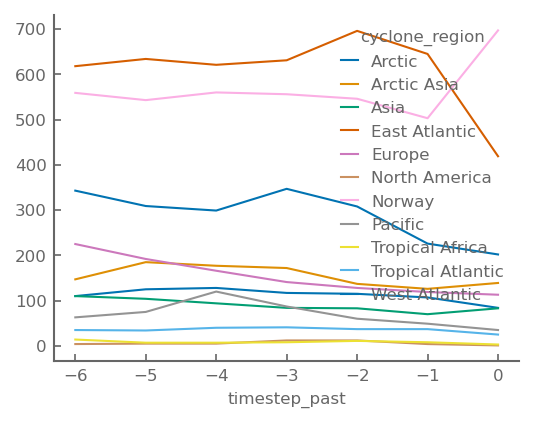

In [44]:
gdf_cyclones.groupby(['timestep_past','cyclone_region']).geometry.count().unstack().plot()

In [7]:
df_pred = ds_predictions.max('dataset').to_dataframe().reset_index()
df_pred['time_of_event'] = df_pred.time+pd.Timedelta('1D')*df_pred.timestep
df_pred['timestep_past'] = -df_pred.timestep
df_pred = df_pred.loc[df_pred.time_of_event.isin(gdf_cyclones.time_of_event)]
pred = df_pred.set_index(['time_of_event','timestep_past']).predictions

gdf_cyclones = gdf_cyclones.set_index(['time_of_event','timestep_past'])
gdf_cyclones['prediction'] = pred
gdf_cyclones = gdf_cyclones.reset_index()
# to_series()

In [ ]:
plot = sns.relplot(gdf_cyclones.query("blob_category=='large positive' & is_cyclone& prediction>.8"), 
                   x='cyclone_x', y='cyclone_y', col='timestep_past', kind='kde', bw_adjust=.5, fill=True, gridsize=64, cmap='magma_r', alpha=.9,
                   facet_kws=dict(subplot_kws=dict(projection=proj)),
                   levels=10, thresh=0.1, height=2, aspect=.8, linewidths=2)
for ax in plot.axes.flat:
    ax.coastlines(lw=.5)

# Plot 0: model skill

In [10]:
p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='val').targets.dropna('time').values.flatten(), ds_predictions.sel(dataset='val').predictions.dropna('time').values.flatten())
print(sklearn.metrics.auc(r,p))


0.31956928805696977


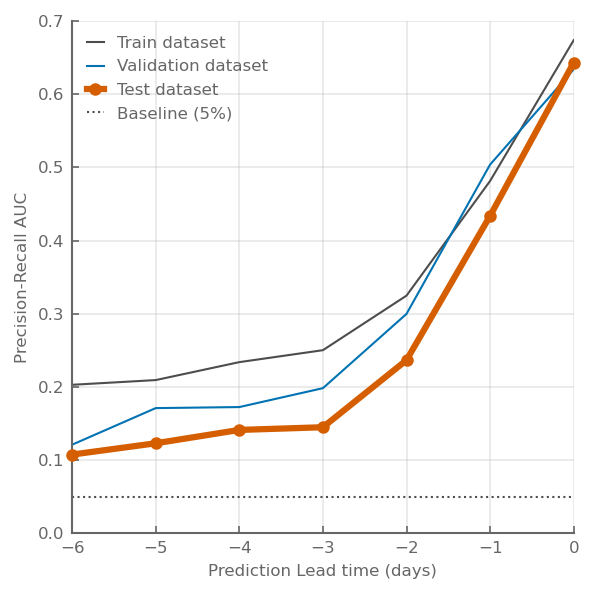

In [11]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.sel(dataset='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='val').targets.dropna('time')[:,k], ds_predictions.sel(dataset='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.sel(dataset='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')
plt.tight_layout()
plt.savefig('plots/model_skill_PR-AUC.svg', dpi=300, transparent=True)

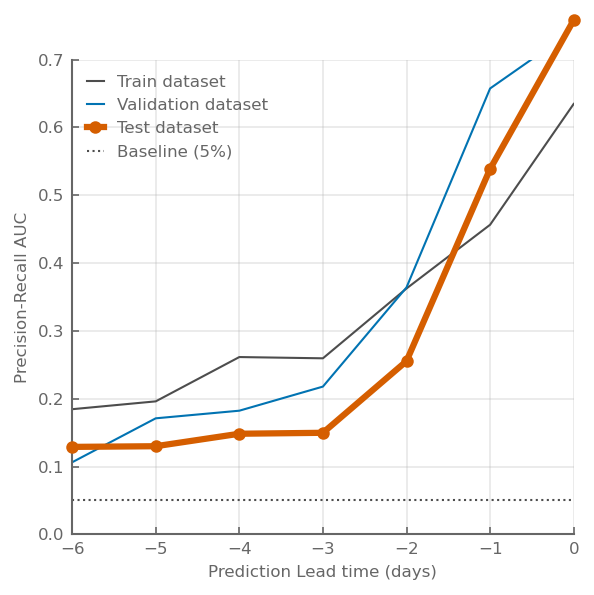

In [12]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='val').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')
plt.tight_layout()

0.6430457623618122
0.43383205982232936
0.2366387629546732
0.14500745816980434
0.14132480956923849
0.12309847405753503
0.10766972164945579


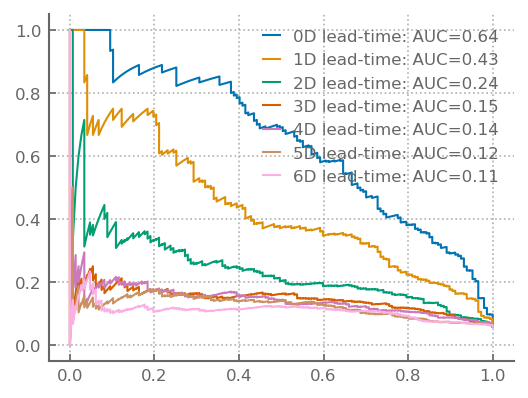

In [13]:
fig, axs = plt.subplots()
import sklearn 
for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.sel(dataset='test').predictions.dropna('time')[:,k])
    plt.plot(r,p, label=f'{k}D lead-time: AUC={sklearn.metrics.auc(r,p):.02f}')
    print(sklearn.metrics.auc(r,p))
plt.grid()
plt.legend()

# targets

In [24]:
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).median()
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).where(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past'])>0.773).idxmin()

<xarray.DataArray 'sample' ()> Size: 8B
array((Timestamp('1982-09-18 00:00:00'), -1), dtype=object)
Coordinates:
    quantile  float64 8B 0.95

# Plot 1: attributions are aggregated

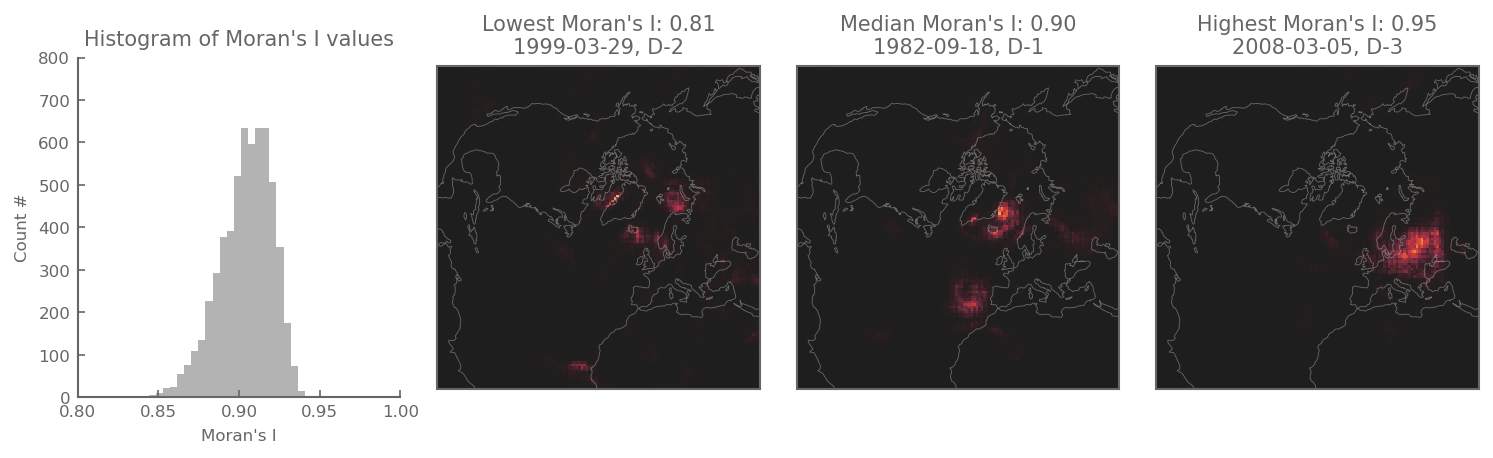

In [25]:
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax().values)
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmin().values)
fig, axs = plt.subplot_mosaic("""ABCD""", figsize=(10,3), 
                              per_subplot_kw=dict(BCD=dict(projection=proj)))
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax()

ds_attrs.moran_I.plot.hist(ax=axs['A'], bins=30, color='.7')
ds_attrs.sel(time_of_event='2018-08-10', timestep_past=-2).lrp_normed.plot(ax=axs['B'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.005)
ds_attrs.sel(time_of_event='1982-09-18', timestep_past=-1).lrp_normed.plot(ax=axs['C'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.005)
ds_attrs.sel(time_of_event='2008-03-05', timestep_past=-3).lrp_normed.plot(ax=axs['D'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.005)


lowest_moran = ds_attrs.sel(time_of_event='2018-08-10', timestep_past=-2).moran_I.values
median_moran = ds_attrs.sel(time_of_event='1982-09-18', timestep_past=-1).moran_I.values
highest_moran = ds_attrs.sel(time_of_event='2008-03-05', timestep_past=-3).moran_I.values

for letter in 'BCD':
    axs[letter].coastlines(color='.7', lw=.4, alpha=.5)
axs['A'].set_title('Histogram of Moran\'s I values')
axs['A'].set(xlabel="Moran's I", ylabel='Count #', xlim=(.8,1.), ylim=(0,800))
axs['B'].set_title(f'Lowest Moran\'s I: {lowest_moran:.02f}\n1999-03-29, D-2')
axs['C'].set_title(f'Median Moran\'s I: {median_moran:.02f}\n1982-09-18, D-1')
axs['D'].set_title(f'Highest Moran\'s I: {highest_moran:.02f}\n2008-03-05, D-3')
plt.tight_layout()
plt.savefig('plots/moranI_examples_lrp_normed_v2.png', dpi=300, transparent=True)

# Plot 2: example to get to blobs and cyclones

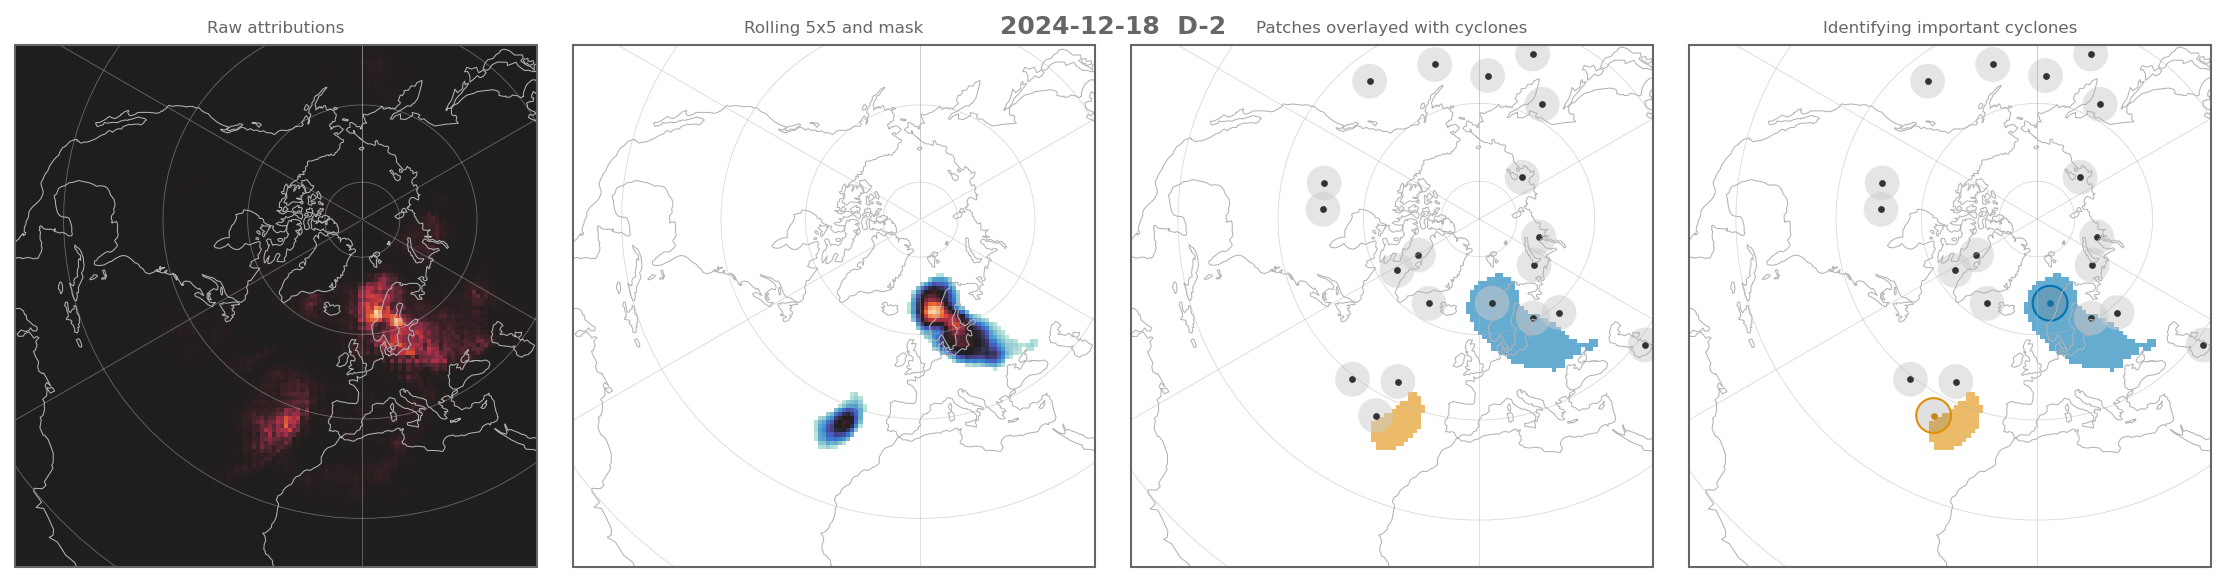

In [134]:
fig, axs = plt.subplot_mosaic("""ABCD""",figsize=(15,4), per_subplot_kw=dict(ABCD=dict(projection=proj)))
data = ds_attrs.lrp_normed.sel(time_of_event='2024-12-18', timestep_past=-2)

data.plot(cmap='icefire', ax=axs['A'], transform=proj, add_colorbar=False)

rolling=5
abs_threshold=0.0005
data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold)
data_rolling = data_rolling/data_rolling.max()
data_rolling.plot(cmap='icefire', ax=axs['B'], transform=proj, add_colorbar=False)

gdf_cyclones_event = gdf_cyclones.set_index(['time_of_event','timestep_past']).loc['2024-12-18'].loc[-2].reset_index()
cyclones_day = all_cyclones.set_index('date').loc['2024-12-16'].reset_index()
cyclone_blobs = all_cyclones.set_index('date').loc['2024-12-16'].reset_index().set_index('track_id').loc[gdf_cyclones_event.query("is_cyclone").cyclone_track_id.values.astype(float)]
cyclone_no_blobs = all_cyclones.set_index('date').loc['2024-12-16'].reset_index().set_index('track_id').drop(cyclone_blobs.index)

axs['C'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
axs['D'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)

for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['C'], transform=proj, alpha=.6)
    
cyclones_day.geometry.buffer(500_000).plot(aspect=1, ax=axs['C'], transform=proj, color='.8', alpha=.5)
cyclones_day.geometry.plot(aspect=1, ax=axs['C'], transform=proj, markersize=5, color='.2')

for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['D'], transform=proj, alpha=.6)
    if line.cyclone_track_id.values[0]!='No cyclone':
        cyclone_ = cyclone_blobs.loc[line.cyclone_track_id.astype(float).values]
        cyclone_.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=f'C{k}')
        cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)
        cyclone_.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor=f'C{k}', )
        # cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)

cyclone_no_blobs.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.8', alpha=.5)
cyclone_no_blobs.geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color='.2')

# cyclone_blobs.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=15, color='C3')
# cyclone_blobs.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor='.3')

for letter in 'ABCD':
    ax = axs[letter]
    ax.set_title('')
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.7'
    )
axs['A'].set_title('Raw attributions', size=8)
axs['B'].set_title('Rolling 5x5 and mask', size=8)
axs['C'].set_title('Patches overlayed with cyclones', size=8)
axs['D'].set_title('Identifying important cyclones', size=8)

plt.suptitle('2024-12-18  D-2', weight = 'bold', size=12, y=.95)
plt.tight_layout()
plt.savefig('plots/example_workflow.png', dpi=300, transparent=True)

In [189]:
_ = gdf_cyclones.set_index(['time_of_event','timestep_past']).loc['2016-08-09'].groupby('cyclone_track_id').cyclone_date.count()


In [197]:
all_cyclones.set_index('track_id').loc[_.index[:-1].astype(float)].reset_index()

,cyclone_track_id,date,msl,lon,lat,x,y,key,geometry
0,777821,2016-07-30,100690.585427,-58.294080,43.671315,-4.509182e+06,-2.785571e+06,2016-07-30 777821,POINT (-4509181.921 -2785571.189)
1,777821,2016-07-31,100053.373818,-39.574157,48.576423,-2.985121e+06,-3.611707e+06,2016-07-31 777821,POINT (-2985120.987 -3611707.037)
2,777821,2016-08-01,99556.035132,-25.695084,52.780180,-1.809871e+06,-3.761461e+06,2016-08-01 777821,POINT (-1809871.483 -3761460.998)
3,777821,2016-08-02,98788.292323,-20.063768,54.907077,-1.344886e+06,-3.682287e+06,2016-08-02 777821,POINT (-1344885.897 -3682287.091)
4,777821,2016-08-03,98899.982760,-9.250286,55.912178,-6.110273e+05,-3.751730e+06,2016-08-03 777821,POINT (-611027.264 -3751730.041)
5,777821,2016-08-04,99328.138938,2.497098,58.096480,1.544326e+05,-3.541203e+06,2016-08-04 777821,POINT (154432.576 -3541203.302)
6,777821,2016-08-05,100305.235223,8.933535,59.544483,5.242491e+05,-3.335013e+06,2016-08-05 777821,POINT (524249.067 -3335012.712)
7,778018,2016-08-02,100277.201591,-1.014153,21.343500,-1.493948e+05,-8.439357e+06,2016-08-02 778018,POINT (-149394.82 -8439357.197)
8,778018,2016-08-03,100209.803201,-5.593265,20.111290,-8.417018e+05,-8.594741e+06,2016-08-03 778018,POINT (-841701.791 -8594741.293)
9,778018,2016-08-04,100403.666267,-9.076245,20.375951,-1.355644e+06,-8.486096e+06,2016-08-04 778018,POINT (-1355643.848 -8486095.62)


<Axes: xlabel='x', ylabel='y'>

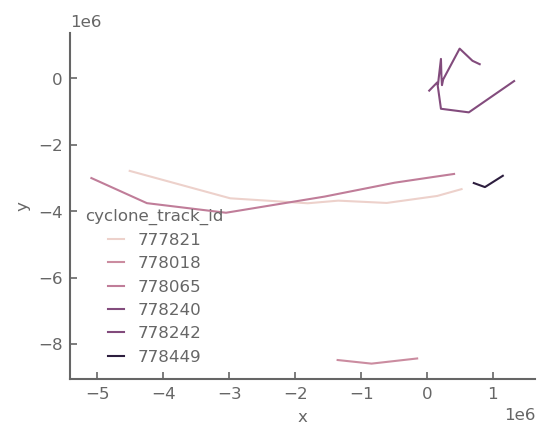

In [200]:
sns.lineplot(all_cyclones.set_index('track_id').loc[_.index[:-1].astype(float)].reset_index(), 
            x='x',y='y',hue='cyclone_track_id')

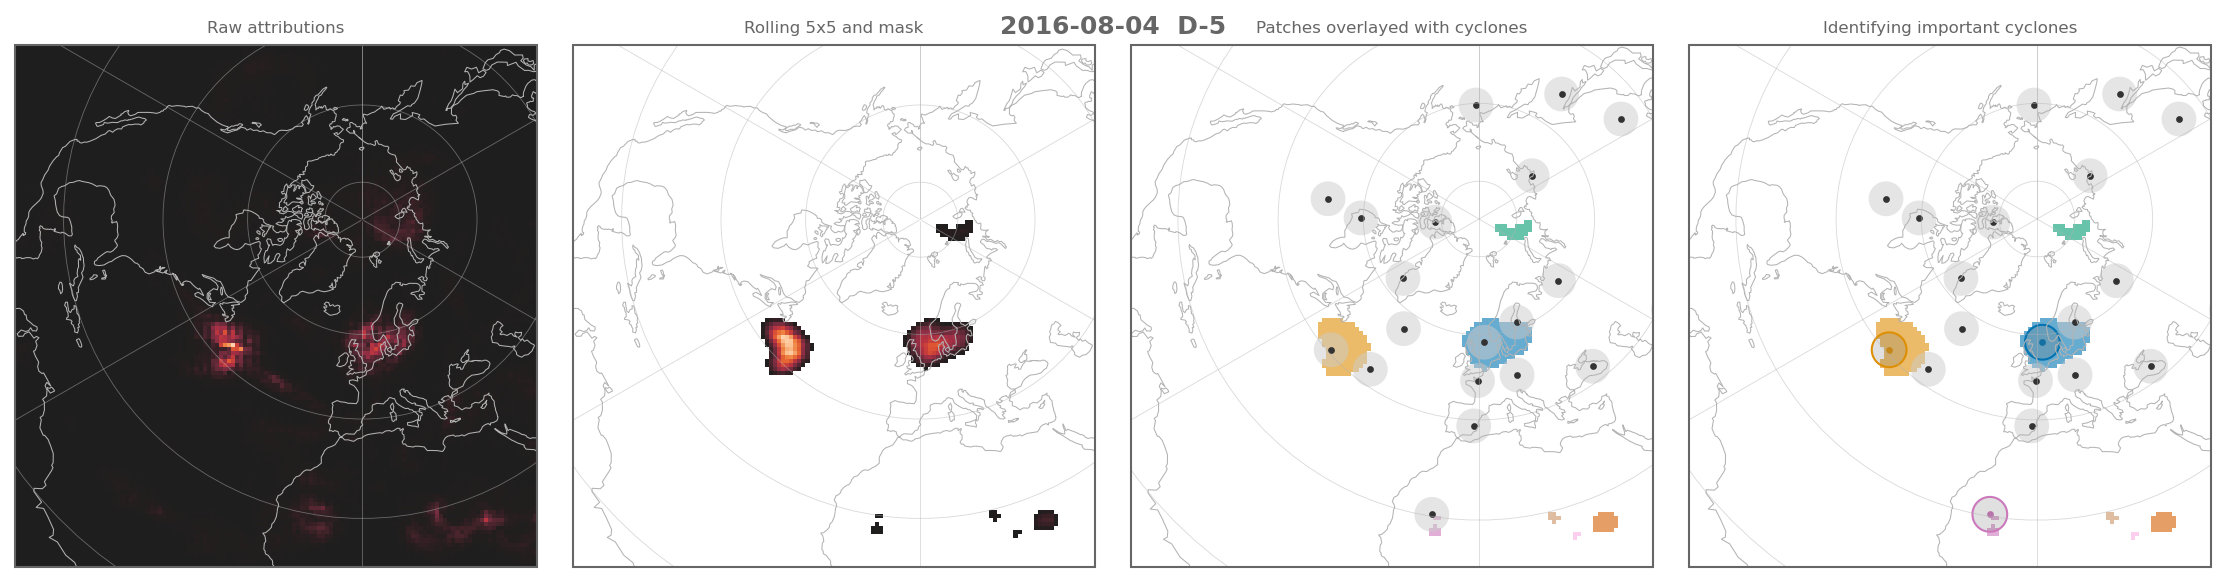

In [ ]:
fig, axs = plt.subplot_mosaic("""ABCD""",figsize=(15,4), per_subplot_kw=dict(ABCD=dict(projection=proj)))
data = ds_attrs.lrp_normed.sel(time_of_event='2016-08-09', timestep_past=-5)

fire_palette = sns.blend_palette(sns.color_palette('icefire', 128)[64:], as_cmap=True)

data.plot(cmap='icefire', ax=axs['A'], transform=proj, add_colorbar=False)

rolling=5
abs_threshold=0.0005
data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold)
data_rolling = data_rolling/data_rolling.max()
data_rolling.plot(cmap=fire_palette, ax=axs['B'], transform=proj, add_colorbar=False)

gdf_cyclones_event = gdf_cyclones.set_index(['time_of_event','timestep_past']).loc['2016-08-09'].loc[-5].reset_index().sort_values('blob_pixel_count', ascending=False)
cyclones_day = all_cyclones.set_index('date').loc['2016-08-04'].reset_index().set_index('track_id')
cyclone_blobs = cyclones_day.loc[gdf_cyclones_event.query("is_cyclone").cyclone_track_id.values.astype(float).astype(int)]
cyclone_no_blobs = cyclones_day.drop(cyclone_blobs.index)

axs['C'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
axs['D'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)

for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['C'], transform=proj, alpha=.6)
    
cyclones_day.geometry.buffer(500_000).plot(aspect=1, ax=axs['C'], transform=proj, color='.8', alpha=.5)
cyclones_day.geometry.plot(aspect=1, ax=axs['C'], transform=proj, markersize=5, color='.2')

for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['D'], transform=proj, alpha=.6)
    if line.cyclone_track_id.values[0]!='No cyclone':
        cyclone_ = cyclone_blobs.loc[line.cyclone_track_id.astype(float).values]
        cyclone_.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=f'C{k}')
        cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)
        cyclone_.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor=f'C{k}', )

cyclone_no_blobs.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.8', alpha=.5)
cyclone_no_blobs.geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color='.2')

for letter in 'ABCD':
    ax = axs[letter]
    ax.set_title('')
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.7'
    )
axs['A'].set_title('Raw attributions', size=8)
axs['B'].set_title('Rolling 5x5 and mask', size=8)
axs['C'].set_title('Patches overlayed with cyclones', size=8)
axs['D'].set_title('Identifying important cyclones', size=8)

plt.suptitle(f"{gdf_cyclones_event.iloc[0].cyclone_date.strftime('%Y-%m-%d')}  D{gdf_cyclones_event.iloc[0].timestep_past}", 
             weight = 'bold', size=12, y=.95)
plt.tight_layout()
plt.savefig('plots/example_workflow.png', dpi=300, transparent=True)

In [245]:
from svg_pltmarker import get_marker_from_svg
custom_marker = get_marker_from_svg(filepath='../plots/plots_leadai/cyclone_symbols2.svg')

In [246]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

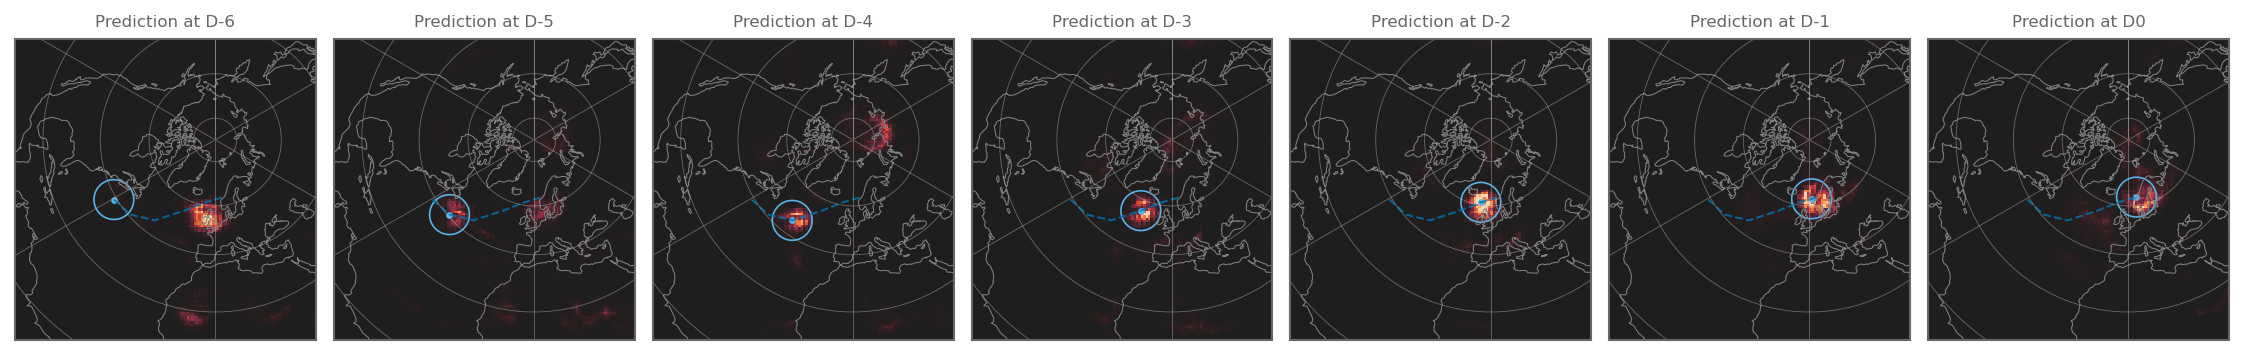

In [265]:
plot = ds_attrs.lrp_normed.sel(time_of_event='2016-08-09').plot(col='timestep_past', cmap='icefire', transform=proj,
                                                         subplot_kws=dict(projection=proj), vmax=.005,
                                                         aspect=.8, size=2.5, add_colorbar=False, rasterized=True)
for k,ax in enumerate(plot.axs.flatten()):
    sns.lineplot(all_cyclones.set_index('track_id').loc[778065].reset_index(), 
            x='x',y='y', ax=ax, legend=False, alpha=.8, ls='--')
    
    all_cyclones.set_index('track_id').loc[778065].iloc[[k]].reset_index().buffer(1_000_000).plot(
            ax=ax, marker='o', color='none', edgecolor='C9', linewidth=.8,
            )
    all_cyclones.set_index('track_id').loc[778065].iloc[[k]].reset_index().plot(
            ax=ax, legend=False, marker='o', color='C9',
            markersize=5)
    
    ax.coastlines(color='.5', lw=.5)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.7'
    )
    ax.set_title(f'Prediction at D{-6+k}', size=8)
plt.savefig('plots/example_cyclone_track_overlay.svg', dpi=300, transparent=True)

In [215]:
all_cyclones.set_index('track_id').loc[778065].iloc[1+k].reset_index()

,index,778065
0,date,2016-08-04 00:00:00
1,msl,99704.904662
2,lon,-48.503729
3,lat,40.786021
4,x,-4248235.370862
5,y,-3758028.308437
6,key,2016-08-04 778065
7,geometry,POINT (-4248235.370861531 -3758028.308437152)


In [204]:
all_cyclones.set_index('track_id')

,date,msl,lon,lat,x,y,key,geometry
track_id,,,,,,,,
0,1979-01-01,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06,1979-01-01 0,POINT (-4859530.961 -1207218.836)
101,1979-01-01,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05,1979-01-01 101,POINT (1464295.962 916766.247)
95,1979-01-01,98798.766080,34.344986,47.073222,2.748557e+06,-4.022446e+06,1979-01-01 95,POINT (2748557.155 -4022446.266)
63,1979-01-01,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,1979-01-01 63,POINT (1089235.315 -5095836.517)
22,1979-01-01,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06,1979-01-01 22,POINT (4445744.614 -1322490.065)
...,...,...,...,...,...,...,...,...
955856,2024-12-30,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05,2024-12-30 955856,POINT (-3522528.207 760527.226)
955852,2024-12-30,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06,2024-12-30 955852,POINT (1011669.113 -8648988.538)
955944,2024-12-30,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06,2024-12-30 955944,POINT (855941.38 -1864881.024)


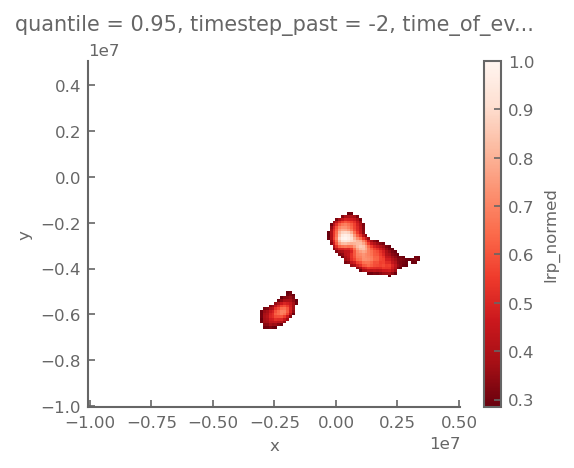

In [135]:
data_rolling.plot(cmap=sns.color_palette('Reds_r', as_cmap=True))

In [126]:
r = gdf_test.geometry.buffer(100_000).area
print(r / (np.pi * 100_000**2))

0     0.998394
1     0.998394
2     0.998394
3     0.998394
4     0.998394
5     0.998394
6     0.998394
7     0.998394
8     0.998394
9     0.998394
10    0.998394
11    0.998394
12    0.998394
13    0.998394
14    0.998394
15    0.998394
16    0.998394
dtype: float64


<GeoAxes: >

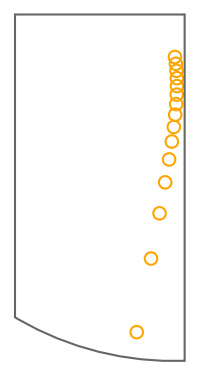

In [114]:
ax = plt.axes(projection=ccrs.NorthPolarStereo())

gdf_test.plot(
    ax=ax,
    facecolor="none",
    edgecolor="orange",
    transform=ccrs.NorthPolarStereo()  # SAME as gdf CRS
)

<Axes: >

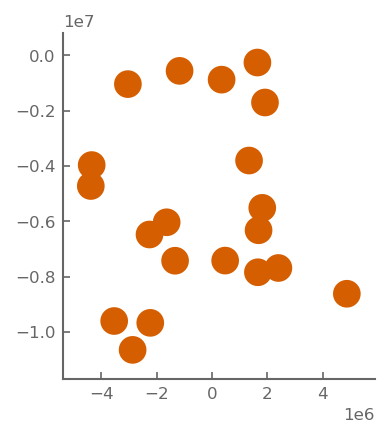

In [90]:
cyclones_day2 = cyclones_day.copy()
cyclones_day2.x += 1e6
# cyclones_day.buffer(500_000).plot()
cyclones_day2.translate(xoff=100000, yoff=-5e6).buffer(500_000).plot(color='C3')

In [50]:
cyclones_day.crs
all_cyclones.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [40]:
cyclones_day = all_cyclones.set_index('date').loc['2024-12-16'].reset_index()
cyclone_blobs = all_cyclones.set_index('date').loc['2024-12-16'].reset_index().set_index('track_id').loc[gdf_cyclones_event.query("is_cyclone").cyclone_track_id.values.astype(float)]
cyclone_no_blobs = all_cyclones.set_index('date').loc['2024-12-16'].reset_index().set_index('track_id').drop(cyclone_blobs.index)

# Plot 3.1 tracking

# Plot 3.0: patches distribution


/tmp/ipykernel_55969/1269784843.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.blob_pixel_count, np.arange(0,1001,5)),


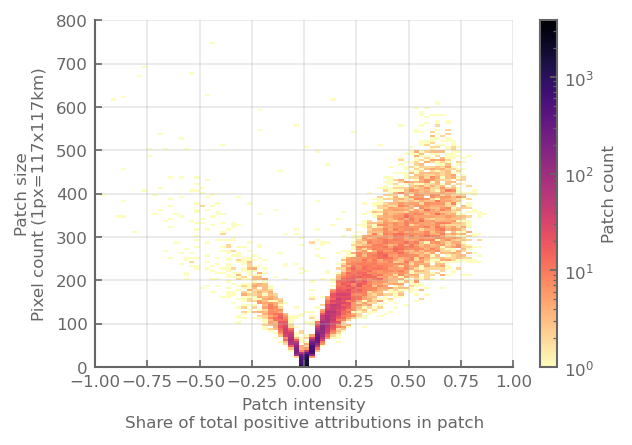

In [15]:
fig, ax = plt.subplots(figsize=(4.5,3))
df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.blob_pixel_count, np.arange(0,1001,5)),
                      pd.cut(gdf_cyclones.blob_attributions, np.arange(-1.5,1.1, .025)),
                      ]).geometry.count().to_xarray().rename('Patch count')
# df_plot['blob_attributions'] = df_blob.blob_attributions*100
df_plot.where(df_plot>=1).plot(norm=LogNorm(), vmin=1, cmap='magma_r')
ax.grid(linestyle='-', alpha=.3, zorder=10)
ax.set(ylim=(0,800), xlim=(-1,1))
# ax.set_ylim(0,50)
ax.set_ylabel('Patch size\nPixel count (1px=117x117km)')
ax.set_xlabel('Patch intensity\nShare of total positive attributions in patch')
plt.savefig('plots/patches_distributions.png', dpi=300, transparent=True)

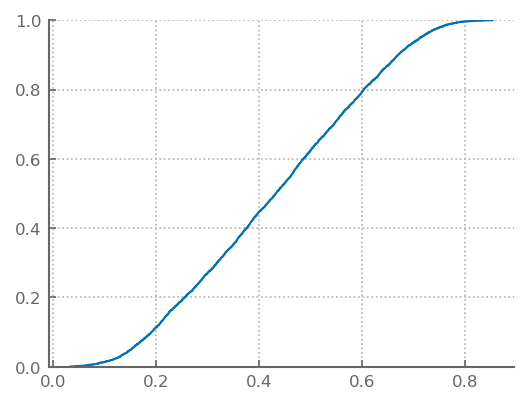

In [16]:
plt.ecdf(gdf_cyclones.groupby(['time_of_event', 'timestep_past']).blob_attributions.max().sort_values())
plt.grid()

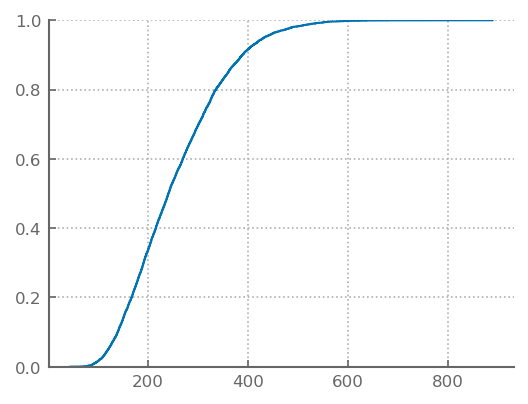

In [14]:
plt.ecdf(gdf_cyclones.groupby(['time_of_event', 'timestep_past']).blob_pixel_count.max().sort_values())
plt.grid()

# Plot 3: there are usually 1-3 large blobs per prediction
"Large blobs" are defined as 25pixels minimum (5x5 square)

In [17]:
categories = np.array(['                     ' for k in gdf_cyclones.index])
categories[((gdf_cyclones.blob_pixel_count<25)).values] = 'small blob'
categories[((np.abs(gdf_cyclones.blob_attributions)<.1)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large neutral'
categories[((gdf_cyclones.blob_attributions<-.1)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large negative'
categories[((gdf_cyclones.blob_attributions>.1)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large positive'
gdf_cyclones['blob_category'] = categories
# gdf_cyclones.category.value_counts().plot.bar()

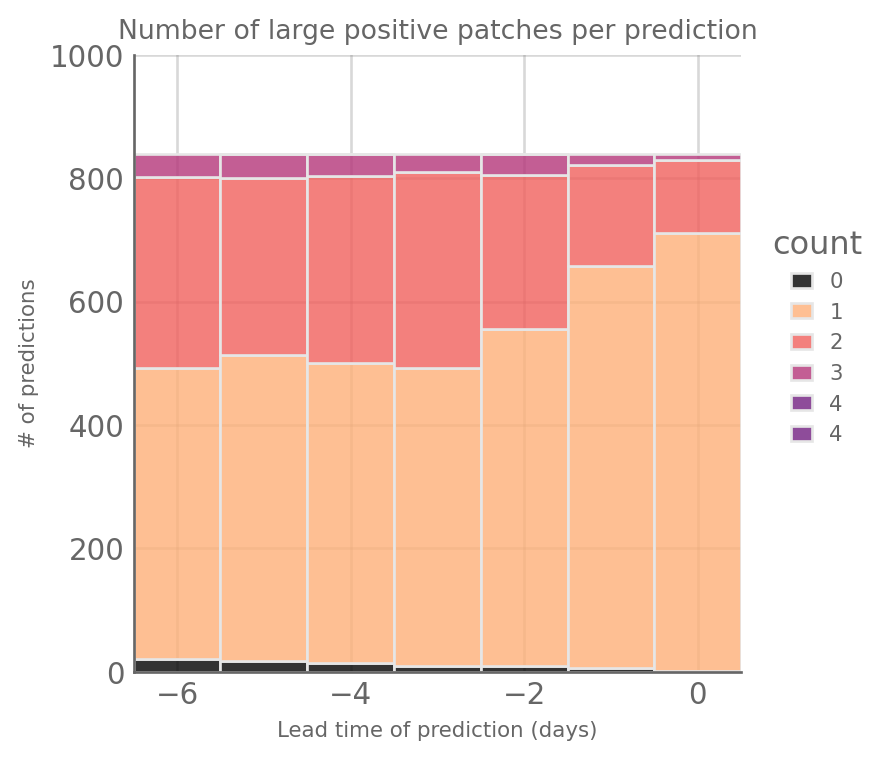

In [18]:
df_plot = gdf_cyclones.query("blob_category=='large positive' ").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Count(),so.Stack(), legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('magma_r', n_colors=5)), order=[0,1,2,3,4,4], ) )
 .layout(size=(4,4))
 .limit(x=(-6.5,0.5), y=(0,1000))
 .label(title='Number of large positive patches per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive blobs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/N_large_patches_per_predictions.svg', dpi=300, transparent=True)

# plt.savefig('plots/N_large_patches_per_predictions.png', dpi=300, transparent=True)

# Plot 4: large blobs are almost always associated with cyclones

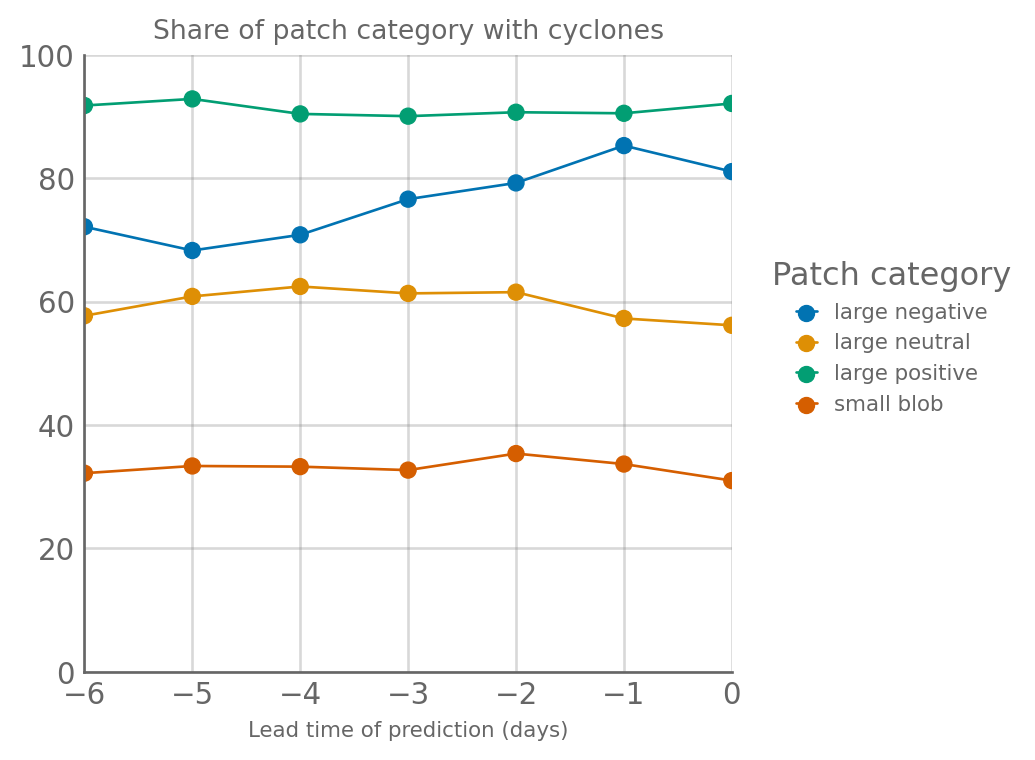

In [19]:
df_plot = (100*(gdf_cyclones.query("is_cyclone").groupby(["blob_category","timestep_past",]).blob_area.count().rename('count'))/(gdf_cyclones.groupby(["blob_category","timestep_past",]).blob_area.count().rename('count'))).rename('percentage').reset_index()

df_plot = df_plot.rename(columns=dict(blob_category='Patch category'))

(so.Plot(df_plot, x='timestep_past', color='Patch category', y='percentage')
 .add(so.Line(),  legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
 .add(so.Dot(),)
#  .facet(col='Patch category')
#  .scale(color=so.Nominal(['0', 'C3']  ) )
 .layout(size=(4,4))
 .limit(x=(-6,0), y=(0,100))
 .label(legen='coucou')
 .label(title='Share of patch category with cyclones', y='', x='Lead time of prediction (days)', legend='Number of large positive blobs', yticks= '{.0f%}%')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/share_of_patches_with_cyclones.svg', dpi=300, transparent=True)


# Plot 5: there are usually 1-2 cyclones used per prediction

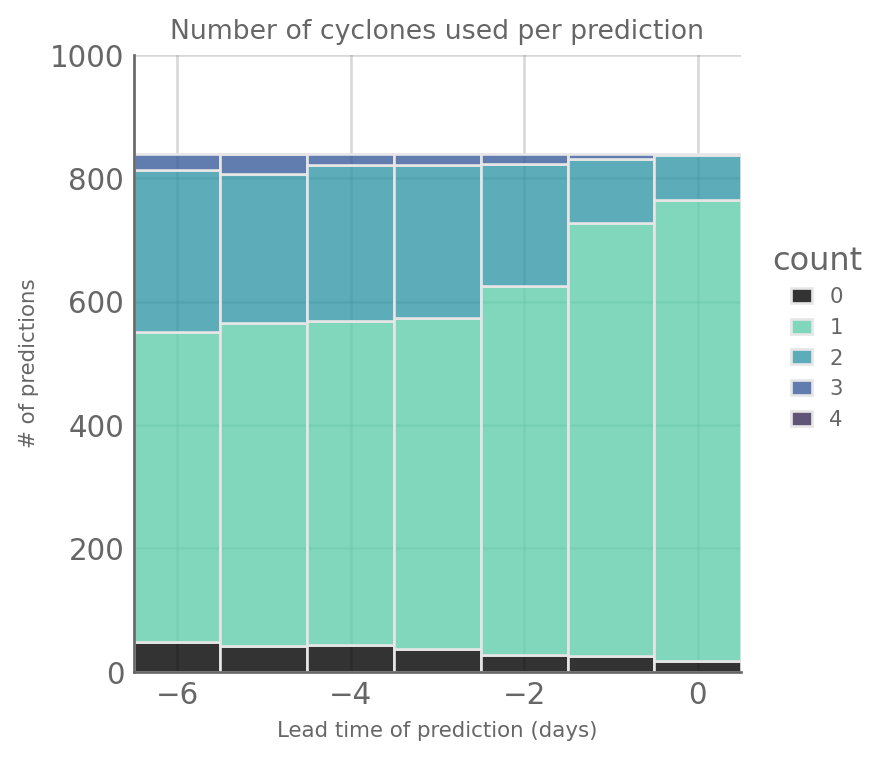

In [20]:
df_plot = gdf_cyclones.query("(blob_category=='large positive') & (is_cyclone)").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
#  .add(so.Area( alpha=.6), so.Count(), so.Stack(), legend=True,)
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Count(),so.Stack(), legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('mako_r', n_colors=4)), order=[0,1,2,3,4], ) )
 .layout(size=(4,4))
 .limit(x=(-6.5,0.5), y=(0,1000))
 .label(title='Number of cyclones used per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive blobs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/cyclones_in_patches_per_prediction.svg', dpi=300, transparent=True)



# Cyclones are in the right place
need map here

In [61]:
space = np.array(['                     ' for k in gdf_cyclones.index])
space[((gdf_cyclones.cyclone_lat>30)&(gdf_cyclones.cyclone_lon<-90)&(gdf_cyclones.cyclone_lon>-120)).values] = 'North America'
space[((gdf_cyclones.cyclone_lat<30)&(gdf_cyclones.cyclone_lon<-90)&(gdf_cyclones.cyclone_lon>-120)).values] = 'Pacific'

space[((gdf_cyclones.cyclone_lat>30)&(gdf_cyclones.cyclone_lon<-40)&(gdf_cyclones.cyclone_lon>-90)).values] = 'West Atlantic'
space[((gdf_cyclones.cyclone_lat>30)&(gdf_cyclones.cyclone_lon<-10)&(gdf_cyclones.cyclone_lon>-40)).values] = 'East Atlantic'

space[((gdf_cyclones.cyclone_lat>50)&(gdf_cyclones.cyclone_lat<80)&(gdf_cyclones.cyclone_lon>-10)&(gdf_cyclones.cyclone_lon<40)).values] = 'Norway'
space[((gdf_cyclones.cyclone_lat<50)&(gdf_cyclones.cyclone_lat>30)&(gdf_cyclones.cyclone_lon>-10)&(gdf_cyclones.cyclone_lon<40)).values] = 'Europe'
space[((gdf_cyclones.cyclone_lat>80)&(gdf_cyclones.cyclone_lon>-10)&(gdf_cyclones.cyclone_lon<40)).values] = 'Arctic Asia'#'Arctic Eurasia'
space[((gdf_cyclones.cyclone_lat>60)&(gdf_cyclones.cyclone_lon>40)&(gdf_cyclones.cyclone_lon<120)).values] = 'Arctic Asia'#'Arctic Eurasia'
space[((gdf_cyclones.cyclone_lat<60)&((gdf_cyclones.cyclone_lon<-120)|(gdf_cyclones.cyclone_lon>120))).values] = 'Pacific'
space[((gdf_cyclones.cyclone_lat>60)&((gdf_cyclones.cyclone_lon<-120)|(gdf_cyclones.cyclone_lon>120))).values] = 'Arctic Pacific'
space[((gdf_cyclones.cyclone_lat<60)&(gdf_cyclones.cyclone_lon>40)&(gdf_cyclones.cyclone_lon<120)).values] = 'Asia'
space[((gdf_cyclones.cyclone_lat<30)&((gdf_cyclones.cyclone_lon>-100)&(gdf_cyclones.cyclone_lon<60))).values] = 'Tropical Atlantic'# 

# space[((gdf_cyclones.cyclone_lat>55)&(gdf_cyclones.cyclone_lon<-10)&(gdf_cyclones.cyclone_lon>-45)).values] = 'North East Atlantic'

# space[((gdf_cyclones.cyclone_lat>30)&(gdf_cyclones.cyclone_lon<40)&(gdf_cyclones.cyclone_lon>-20)).values] = 'Atlantic North East'
# space[((gdf_cyclones.cyclone_lat>30)&(gdf_cyclones.cyclone_lon<-20)&(gdf_cyclones.cyclone_lon>-100)).values] = 'Atlantic North West'
# space[((gdf_cyclones.cyclone_lat<60)&((gdf_cyclones.cyclone_lon<-100)|(gdf_cyclones.cyclone_lon>120))).values] = 'Pacific'
# space[((gdf_cyclones.cyclone_lat>60)&((gdf_cyclones.cyclone_lon<-100)|(gdf_cyclones.cyclone_lon>120))).values] = 'Arctic Pacific'
# space[((gdf_cyclones.cyclone_lat>60)&(gdf_cyclones.cyclone_lon>40)&(gdf_cyclones.cyclone_lon<120)).values] = 'Arctic Eurasia'
# space[((gdf_cyclones.cyclone_lat<60)&(gdf_cyclones.cyclone_lon>40)&(gdf_cyclones.cyclone_lon<120)).values] = 'Eurasia'

# space[((gdf_cyclones.cyclone_lat<30)&((gdf_cyclones.cyclone_lon>-100)&(gdf_cyclones.cyclone_lon<60))).values] = 'Tropical Atlantic'

gdf_cyclones['cyclone_region2'] = space

<GeoAxes: >

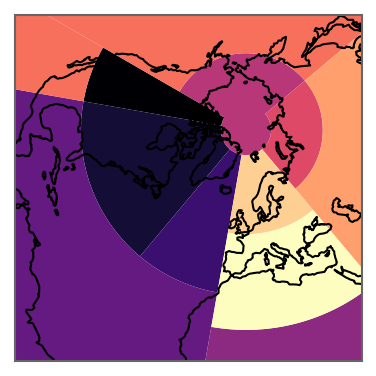

In [2]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(subplot_kw=dict(projection=proj))

ax.coastlines()
ax.set_extent((-1e7, 5e6, -1e7, 5e6), crs=proj)
import numpy as np
from shapely.geometry import Polygon
import shapely
# from shapely.ops import cascaded_union

def get_polygon(lon_min, lon_max, lat_min, lat_max,
                polygon_kwargs = dict(closed=True, facecolor='orange', alpha=0.5)):
    points_lon = list(np.linspace(lon_min, lon_max, 100)) + [lon_max for k in range(100)] + list(np.linspace(lon_max, lon_min, 100)) + [lon_min for k in range(100)]
    points_lat =  [lat_min for k in range(100)] + list(np.linspace(lat_min, lat_max, 100)) + [lat_max for k in range(100)]+ list(np.linspace(lat_max, lat_min, 100))
    vertices = list(zip(points_lon, points_lat))
    polygon_patch = mpatches.Polygon(vertices, transform=ccrs.PlateCarree(), **polygon_kwargs)
    return polygon_patch



def get_shapely_polygon(lon_min, lon_max, lat_min, lat_max,):
    points_lon = list(np.linspace(lon_min, lon_max, 100)) + [lon_max for k in range(100)] + list(np.linspace(lon_max, lon_min, 100)) + [lon_min for k in range(100)]
    points_lat =  [lat_min for k in range(100)] + list(np.linspace(lat_min, lat_max, 100)) + [lat_max for k in range(100)]+ list(np.linspace(lat_max, lat_min, 100))
    
    vertices = list(zip(points_lon, points_lat))
    polygon = Polygon(vertices, )
    return polygon

poly1 = get_shapely_polygon(-100,-120,30,80,)
poly2 = get_shapely_polygon(-40,-100,30,80)
poly3 = get_shapely_polygon(-10,-40,30,80)
poly4 = get_shapely_polygon(-100,-10,-10,30)
poly5 = get_shapely_polygon(-10,50,-10,20)

poly6 = get_shapely_polygon(130,360-120,60,90)
poly7 = get_shapely_polygon(0,360,80,90)

poly8 = get_shapely_polygon(130,40,60,80)
poly9 = get_shapely_polygon(130,360-120,0,60)
poly10 = get_shapely_polygon(-100,-120,0,30)

poly11 = get_shapely_polygon(130,40,0,60)
poly12 = get_shapely_polygon(-10,40,50,80)
poly13 = get_shapely_polygon(-10,40,20,50)

palette = sns.color_palette(sns.color_palette('rocket',7)[1:6][::-1] + sns.color_palette('mako',6)[-5:])

gdf_sectors = gpd.GeoDataFrame(geometry=[poly1,
                                 poly2,
                                 poly3,
                                 poly4,
                                 poly5,
                                 shapely.unary_union([poly6,poly7]),
                                 poly8,
                                 shapely.unary_union([poly9,poly10]),
                                 poly11,
                                 poly12,
                                 poly13
                                 ], 
                        index = ['North America',
                                'West Atlantic',
                                'East Atlantic',
                                'Tropical Atlantic',
                                'Tropical Africa',
                                'Arctic',
                                'Arctic Asia',
                                'Pacific',
                                'Asia',
                                'Norway',
                                'Europe'
                                ],         
                        crs=ccrs.PlateCarree())
gdf_sectors.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='magma', legend=True)


In [ ]:
from shapely.geometry import Point
geometry = [Point(xy) for xy in zip(gdf_cyclones.cyclone_lon, gdf_cyclones.cyclone_lat)]

# create GeoDataFrame
gdf_cyclones_center = gpd.GeoDataFrame(
    geometry=geometry,
    crs="EPSG:4326"   # WGS84 lon/lat
)
cyclones_with_sector = gpd.sjoin(
    gdf_cyclones_center.to_crs(proj),
    gdf_sectors.to_crs(proj),
    how="left",
    predicate="within"   # or "intersects" if needed
)
gdf_cyclones['cyclone_region'] = cyclones_with_sector.index_right

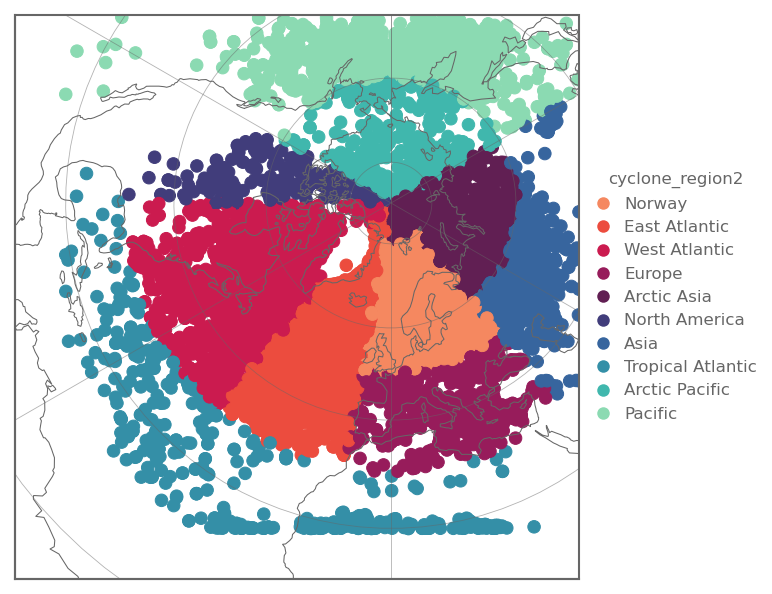

In [64]:
# fig, ax =plt.subplots(subplot_kw=dict(projection=proj), figsize=(6,6))
# daily_cycs = pd.concat(all_df_dailys)

# cyclones_gdf.loc['2000'].plot.scatter(x='x',y='y', ax=ax, transform=proj)
# cyclones_gdf.loc['2000'].plot.scatter(x='lon',y='lat', ax=ax, transform=ccrs.PlateCarree())
palette = sns.color_palette(sns.color_palette('rocket',7)[1:6][::-1] + sns.color_palette('mako',6)[-5:])

plot = sns.relplot(gdf_cyclones.query("cyclone_region2!='                     '"), x='cyclone_x', y='cyclone_y', hue='cyclone_region2', transform=proj, edgecolor=None,
                palette=palette, facet_kws=dict(subplot_kws=dict(projection=proj)), height=4,
                hue_order=['Norway','East Atlantic','West Atlantic' ,'Europe', 'Arctic Asia',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific'])
ax = plot.axes.flat[0]
ax.coastlines(color='.4', lw=.5)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
# sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.4'
)
# gl.ylines=False

ax.set_extent((-1e7,5e6,-1e7,5e6), crs=proj)

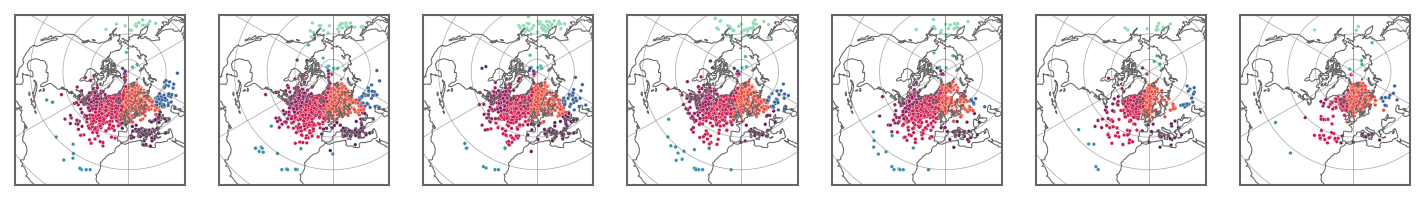

In [62]:
fig, axs = plt.subplots(1,7, subplot_kw=dict(projection=proj), figsize=(12,3))
df_used = gdf_cyclones.query("blob_category=='large positive'")
for k, ax in enumerate(axs):
    sns.scatterplot(df_used.loc[df_used.timestep_past==-6+k].query("cyclone_region2!='                     '"), 
                x='cyclone_x', y='cyclone_y', hue='cyclone_region2', transform=proj, edgecolor='1',
                palette=palette,ax=ax,
                hue_order=['Norway','East Atlantic','West Atlantic' ,'Europe','Arctic Asia',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific'], legend=False, s=3)
    ax.coastlines(color='.4', lw=.5)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.4'
    )
    ax.set_extent((-1e7,5e6,-1e7,5e6), crs=proj)

In [152]:
all_preds_cycs = []
for (pred_min, pred_max) in [[0.1*k,0.1*(k+1)] for k in range(10)]:
    df_counts = gdf_cyclones.query("blob_category=='large positive'").groupby(['time_of_event','timestep_past','cyclone_region2']).agg(dict(cyclone_msl='count', prediction='mean'))#.dropna()
    df_counts = df_counts.query("cyclone_msl>0 & prediction>@pred_min & prediction<=@pred_max").reset_index().groupby(['timestep_past','cyclone_region2']).time_of_event.count()

    all_preds = gdf_cyclones.query("prediction>@pred_min & prediction<=@pred_max").groupby(['time_of_event','timestep_past']).cyclone_msl.count().reset_index().groupby('timestep_past').cyclone_msl.count()
    # df_counts
    all_preds_cycs.append((df_counts.unstack().T.fillna(0)/all_preds).stack().to_xarray().assign_coords(pred_bin=pred_max))

ds_cycs_ = xr.concat(all_preds_cycs, dim='pred_bin')

/tmp/ipykernel_2924815/2226949225.py:10: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'cyclone_region2' ('cyclone_region2',) The recommendation is to set join explicitly for this case.
  ds_cycs_ = xr.concat(all_preds_cycs, dim='pred_bin')
/tmp/ipykernel_2924815/2226949225.py:10: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'timestep_past' ('timestep_past',) The recommendation is to set join explicitly for this case.
  ds_cycs_ = xr.concat(all_preds_cycs, dim='pred_bin')


/tmp/ipykernel_55969/1073908980.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_all_counts.cyclone_msl[df_all_counts.cyclone_msl>0] = np.nan
/tmp/ipykernel_55969/1073908980.py:6: SettingWithCopyWarning: 
A value is trying to be set on

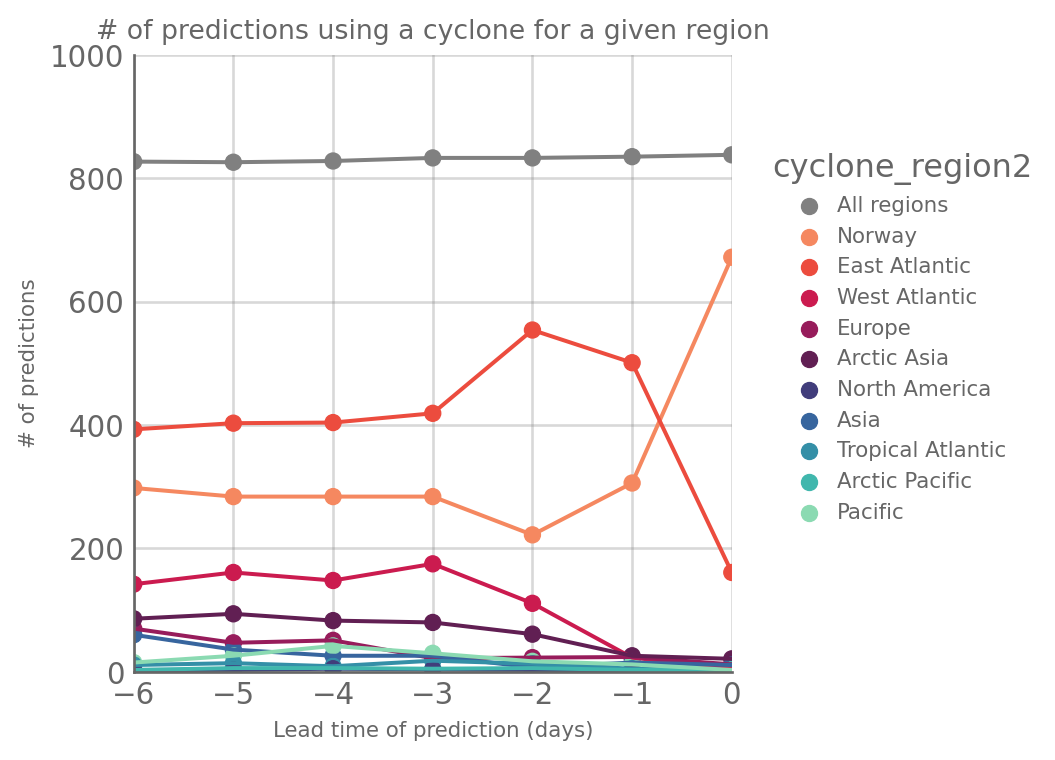

In [68]:
df_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past','cyclone_region2']).cyclone_msl.count().reset_index()
df_counts = df_counts.query("cyclone_msl>0")
df_all_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past']).cyclone_msl.count().reset_index()
df_all_counts['cyclone_region2'] = 'All regions'
df_all_counts = df_all_counts
df_all_counts.cyclone_msl[df_all_counts.cyclone_msl>0] = np.nan
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='cyclone_region2', linewidth='cyclone_region2', y='timestep_past')
 .add(so.Lines(), so.Count(),  legend=False)
#  .add(so.Line(linewidth=3), so.Count(), , data=df_all_counts)
 .add(so.Dot(), so.Count(), )
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['.5']+palette,
                         order=['All regions',
                                'Norway','East Atlantic','West Atlantic' ,'Europe', 'Arctic Asia',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific', 
                                ]),
       linewidth=so.Nominal([1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,3],
                            order=['All regions','Europe', 'Arctic Pacific','Arctic Asia', 'West Atlantic', 'East Atlantic',
                        'Norway', 'Asia', 'North America', 'Pacific', 'Tropical Atlantic',
                        ]),
       )

 .layout(size=(4,4))
  .limit(x=(-6,0), y=(0,1000))
 .label(title='# of predictions using a cyclone for a given region')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 .label(legend="Measurement", y='# of predictions', x='Lead time of prediction (days)')
 ).plot().save('plots/cyclone_area.svg', dpi=300, transparent=True)


# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)


In [67]:
df_counts

,time_of_event,timestep_past,cyclone_region2,cyclone_msl
0,1979-01-07,-6,Europe,1.0
1,1979-01-07,-5,Europe,1.0
2,1979-01-07,-4,West Atlantic,1.0
3,1979-01-07,-3,West Atlantic,1.0
4,1979-01-07,-2,East Atlantic,1.0
...,...,...,...,...
5815,2024-12-29,-4,All regions,NaN
5816,2024-12-29,-3,All regions,NaN
5817,2024-12-29,-2,All regions,NaN
5818,2024-12-29,-1,All regions,NaN


In [70]:
def find_top_cyc(df):
    out = df.query("cyclone_track_id != 'No cyclone' &(blob_category=='large positive')")
    if out.index.size==0:
        return 'No cyclone'
    else:
        return out.iloc[out.blob_attributions.argmax()].cyclone_region2

top_cycs = gdf_cyclones.reset_index().groupby(['time_of_event','timestep_past']).apply(
    find_top_cyc
)
top_cycs = top_cycs.rename('main_cyclone_region').reset_index()#.fillna('No cyclone')


/tmp/ipykernel_55969/312562678.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cycs = gdf_cyclones.reset_index().groupby(['time_of_event','timestep_past']).apply(


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/properties.py:130: UserWarning: The color list has more values (11) than needed (10), which may not be intended.
  warnings.warn(message, UserWarning)


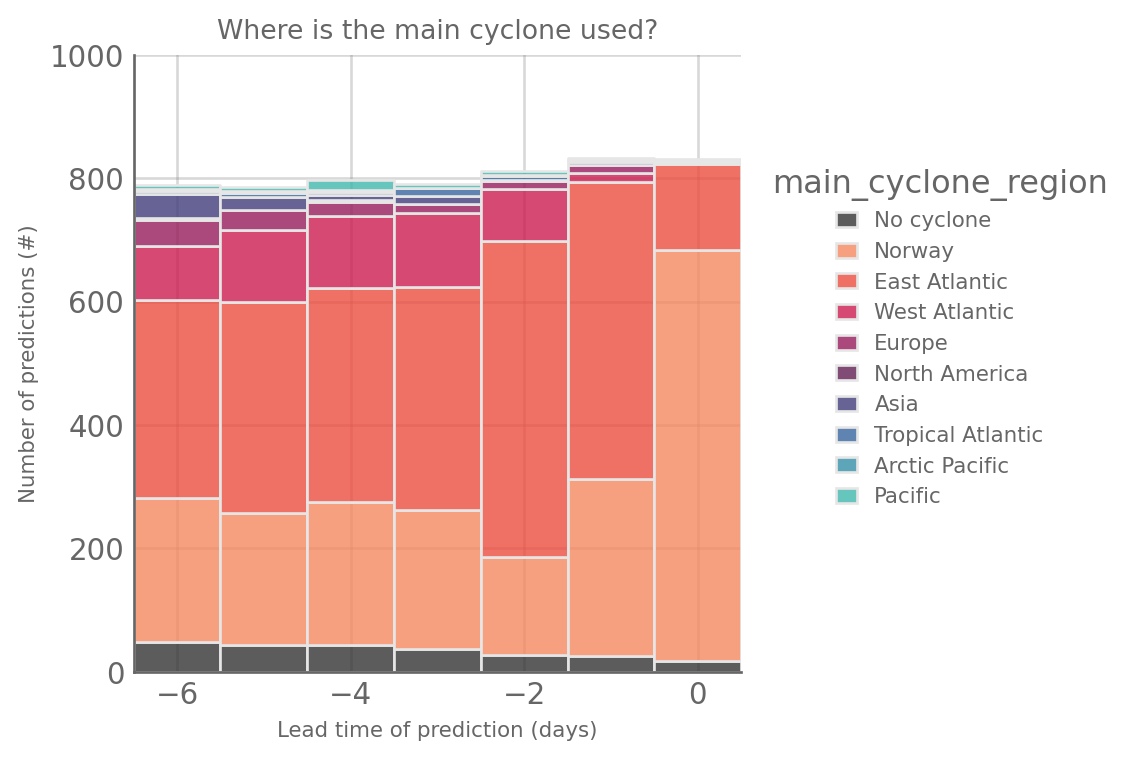

In [71]:

df_count = top_cycs.groupby(['timestep_past','main_cyclone_region']).time_of_event.count().rename('count').unstack().fillna(0).stack().reset_index().rename(columns={0:'count'})
df_count['main_cyclone_region'] = pd.Categorical(df_count["main_cyclone_region"], categories=['No cyclone',
                                'Norway','East Atlantic','West Atlantic' ,'Europe',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific', 
                                ], ordered=True)
(so.Plot(df_count.sort_values('main_cyclone_region'), x='timestep_past', color='main_cyclone_region',y='count')
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Stack(), legend=True)
  .scale(color=so.Nominal(['.2']+ palette,
                         order=['No cyclone',
                                'Norway','East Atlantic','West Atlantic' ,'Europe',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific', 
                                ]))


 .layout(size=(4,4))
  .limit(x=(-6.5,0.5), y=(0,1000))
 .label(title='Where is the main cyclone used?')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 .label(legend="Measurement", x='Lead time of prediction (days)', y='Number of predictions (#)')
 )
#.plot().save('plots/cyclone_area.svg', dpi=300, transparent=True)


# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)


In [18]:
df_counts.query('timestep_past==-6').groupby(['cyclone_region']).timestep_past.count().sort_values(ascending=False).iloc[1:]

cyclone_region
Atlantic North West    586
Atlantic North East    473
Arctic Eurasia         108
Pacific                 97
Tropical Atlantic       65
Arctic Pacific          52
Eurasia                 42
Name: timestep_past, dtype: int64

In [16]:
gdf_cyclones.time_of_event.unique()

<DatetimeArray>
['1979-01-07 00:00:00', '1979-03-03 00:00:00', '1979-03-04 00:00:00',
 '1979-03-05 00:00:00', '1979-08-14 00:00:00', '1979-09-11 00:00:00',
 '1979-09-13 00:00:00', '1979-09-17 00:00:00', '1979-09-18 00:00:00',
 '1979-09-19 00:00:00',
 ...
 '2024-10-23 00:00:00', '2024-10-22 00:00:00', '2024-10-27 00:00:00',
 '2024-10-31 00:00:00', '2024-11-16 00:00:00', '2024-12-01 00:00:00',
 '2024-12-13 00:00:00', '2024-12-15 00:00:00', '2024-12-18 00:00:00',
 '2024-12-29 00:00:00']
Length: 928, dtype: datetime64[ms]

/tmp/ipykernel_2263492/879356471.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_blob_cycs.groupby(["timestep_past","time_of_event",
/tmp/ipykernel_2263492/879356471.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()


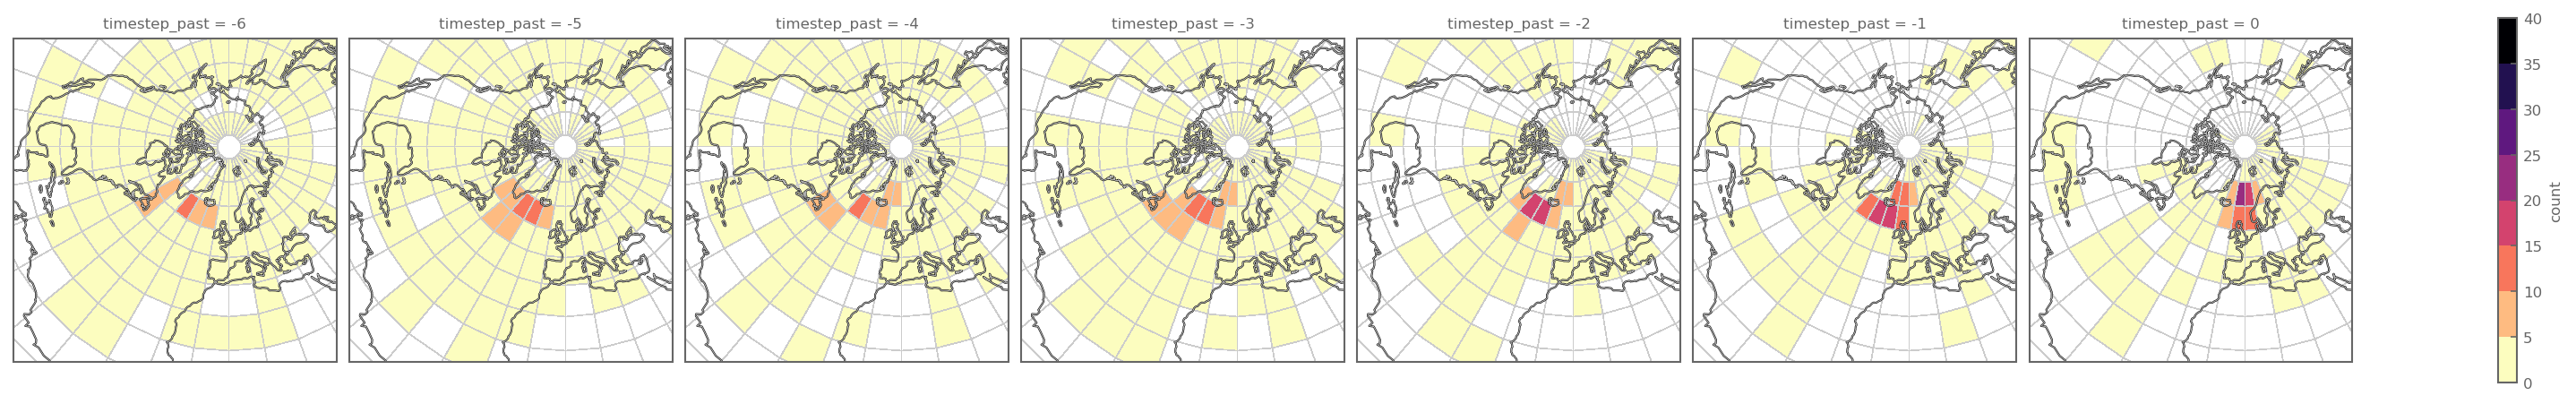

In [ ]:
pos_blob_cycs = gdf_cyclones.query("is_cyclone&(blob_category=='large positive')")
df_ = pos_blob_cycs.groupby(["timestep_past","time_of_event", 
                       pd.cut(pos_blob_cycs.cyclone_lon, np.arange(-190,181,10)),
                       pd.cut(pos_blob_cycs.cyclone_lat, np.arange(-45,91,10))]).geometry.count().rename('count').reset_index()
df_['count_one'] = df_['count']>0
df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()
df_['cyclone_lon'] = [k.mid for k in df_.cyclone_lon]
df_['cyclone_lat'] = [k.mid for k in df_.cyclone_lat]

ds_ = df_.set_index(['timestep_past','cyclone_lon','cyclone_lat'])['count'].to_xarray()/928*100

plot = ds_.where(ds_>0).plot(col='timestep_past', transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='cyclone_lon', y='cyclone_lat', cmap='magma_r',
         levels=[0,5,10,15,20,25,30,35,40], edgecolors='.8', linewidth=.3)

for ax in plot.axs.flatten():
    # ax.coastlines()
    ax.set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    # gl = ax.gridlines(
    #     crs=ccrs.PlateCarree(),
    #     draw_labels=False,       # add tick labels
    #     linewidth=0.4,
    #     linestyle="-",
    #     alpha=0.5,
    #     zorder=2,
    #     color='.7'
    # )
    # gl.ylines=False


In [162]:
all_cyclones

,date,track_id,msl,lon,lat,x,y,key,geometry
0,1979-01-01,0.0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06,1979-01-01 0.0,POINT (-4859530.96139 -1207218.83636)
1,1979-01-01,101.0,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05,1979-01-01 101.0,POINT (1464295.96158 916766.24675)
2,1979-01-01,67.0,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06,1979-01-01 67.0,POINT (1927226.7302 -4544065.05764)
3,1979-01-01,63.0,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,1979-01-01 63.0,POINT (1089235.31533 -5095836.51674)
4,1979-01-01,22.0,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06,1979-01-01 22.0,POINT (4445744.6143 -1322490.06499)
...,...,...,...,...,...,...,...,...,...
290206,2024-12-30,955856.0,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05,2024-12-30 955856.0,POINT (-3522528.20672 760527.22572)
290207,2024-12-30,955852.0,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06,2024-12-30 955852.0,POINT (1011669.11336 -8648988.53791)
290208,2024-12-30,955944.0,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06,2024-12-30 955944.0,POINT (855941.38005 -1864881.02438)
290209,2024-12-31,955936.0,97715.058098,170.721027,60.375923,5.288183e+05,3.236749e+06,2024-12-31 955936.0,POINT (528818.29025 3236748.6743)


ValueError: Could not interpret value `x` for `x`. An entry with this name does not appear in `data`.

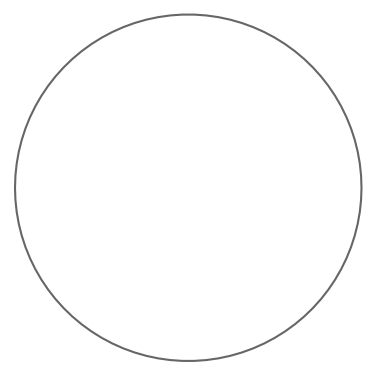

In [82]:
fig, ax = plt.subplots(figsize=(6,3),subplot_kw = dict(projection=proj))
sns.kdeplot(pos_blob_cycs, x='x', y='y', fill=True, transform=proj, cmap='magma_r')
ax.set_extent([-1e7, 5e6, -1e7, 0e6], crs=proj)
ax.coastlines(color='.6', lw=1)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)


/tmp/ipykernel_1862689/4051974330.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_blob_cycs.groupby([


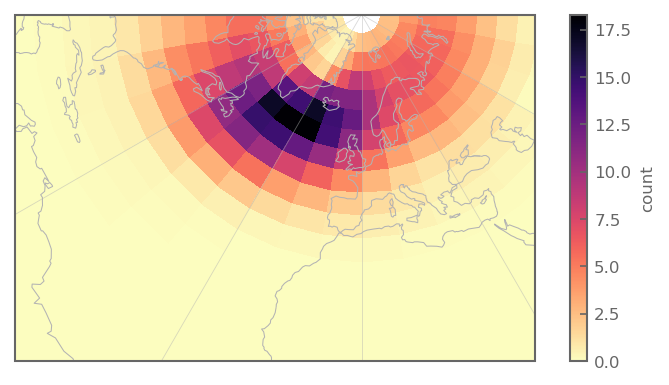

In [83]:
pos_blob_cycs = all_cyclones.query("lat>0").query("msl<99000")
df_ = pos_blob_cycs.groupby([ 
                       pd.cut(pos_blob_cycs.lon, np.arange(-190,181,10)),
                       pd.cut(pos_blob_cycs.lat, np.arange(-45,91,5))]).geometry.count().rename('count').reset_index()
df_['lon'] = [k.mid for k in df_.lon]
df_['lat'] = [k.mid for k in df_.lat]

ds_ = df_.set_index(['lon','lat'])['count'].to_xarray()/46

plot = ds_.rolling(lon=3, lat=3, center=True).mean().ffill('lon').bfill('lon').plot( transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='lon', y='lat', cmap='magma_r',
         edgecolors='none', linewidth=.3, aspect=2, size=3)

# for ax in plot.axes.flatten():
ax = plot.axes
ax.set_extent([-1e7, 5e6, -1e7, 0e6], crs=proj)
ax.coastlines(color='.7', lw=.5)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)
gl.ylines=False


In [145]:
df = pd.read_csv('/home/rogui7909/code/predict_rain_norway/bonus/table(5).csv', sep=';', decimal=",").dropna()
df = df.iloc[:,[0,2,3]].dropna()
df.columns = ['station','time','pr']
df['time'] = pd.to_datetime(df.time, format = "%d.%m.%Y",)
df = df.set_index(['time','station'])
df['pr'] = df.pr.astype(float).clip(0)
df['pr'] = df['pr'].where(df['pr']>0).fillna(0)
df = df.unstack().pr.loc['2000':'2024']

In [ ]:
df.dropna().mean()*365.25

Bergen - Florida
(1, 1000]    13.522245
(-1, 1]      11.477070
Name: count, dtype: float64

In [153]:
pd.cut(df.iloc[:,0], [-1,1,1000]).value_counts()/25

Bergen - Florida
(1, 1000]    197.56
(-1, 1]      167.68
Name: count, dtype: float64

IndexError: tuple index out of range

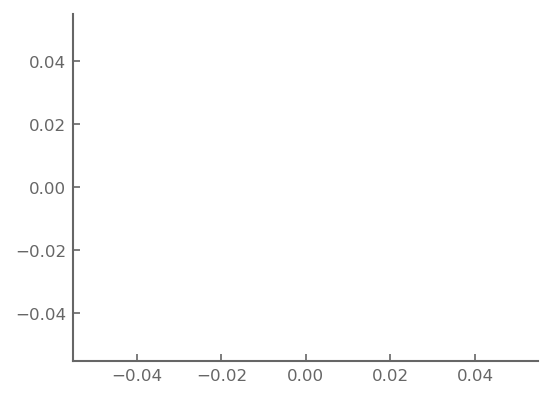

In [110]:
df.pr.plot.hist(bins=[0])